In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv(DATA_DIR / "breast_cancer_logistic.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")])
display(df.head())
display(df["diagnosis"].value_counts().rename_axis("diagnosis").reset_index(name="count"))

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,diagnosis,count
0,B,357
1,M,212


In [3]:
X = df.drop(columns=["id", "diagnosis"])
y = LabelEncoder().fit_transform(df["diagnosis"])  # B=0, M=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_test, proba):.3f}")
print(classification_report(y_test, pred, target_names=["benign", "malignant"]))

Accuracy: 0.965
ROC AUC:  0.996
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



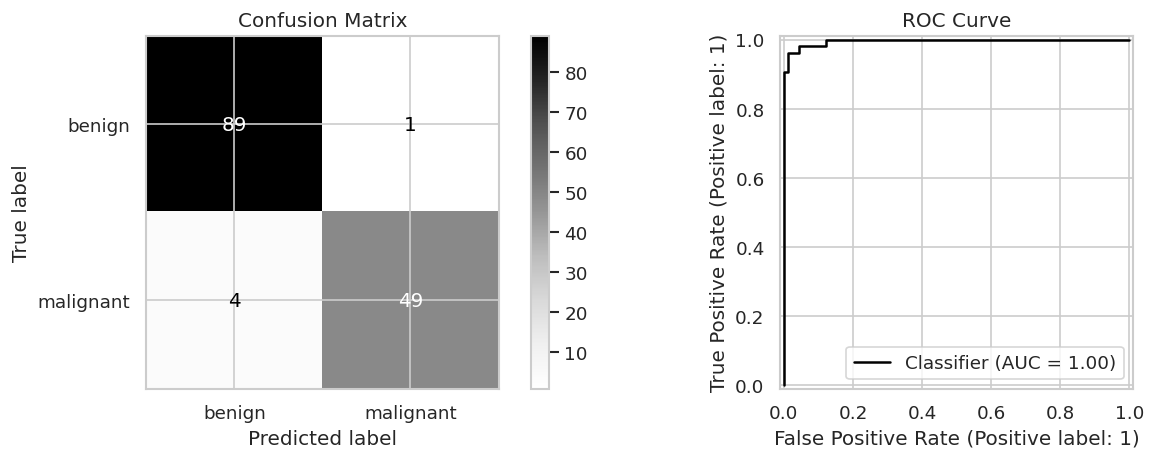

,feature,coefficient,abs_coefficient
21,texture_worst,1.365780,1.365780
10,radius_se,1.267201,1.267201
28,symmetry_worst,1.036496,1.036496
7,concave points_mean,0.963006,0.963006
15,compactness_se,-0.927483,0.927483
23,area_worst,0.889377,0.889377
20,radius_worst,0.887040,0.887040
13,area_se,0.878478,0.878478
6,concavity_mean,0.874054,0.874054
26,concavity_worst,0.867881,0.867881


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["benign", "malignant"], ax=axes[0], cmap="Greys"
)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], color="black")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": model.named_steps["logreg"].coef_[0],
    }
).assign(abs_coefficient=lambda d: d["coefficient"].abs())
display(coef_df.sort_values("abs_coefficient", ascending=False).head(12))